# Cruise Control Hybrid Automaton

This notebook demonstrates the running of a hybrid automaton implementation for `v0.0.4` of the hybrid-automaton pythonic API framework for hybrid automaton creation as well as some evaluation of how it runs.

## Structure Initialization

Initially we retrieve the already defined pythonic `amd (automaton model definition)` definition for the hybrid autoamton. When we print it's `__str__` function we see the AMDL represenation, and when we use `__repr__` we see the .mmd file represenation of the automaton which we can use for generatation of `https://mermaid.live/` state diagrams for visual analysis of the formalized automaton for further how this is implemented please have a look at the bouncing ball source code in `hybrid_automatons` pkg.

![Cruise Control Diagram](./figures/cruise_control_hybrid_automaton.png)

In [1]:
from hybrid_automatons import cruise_control
from hybrid_automaton import Automaton
from hybrid_automaton_runner import AutomatonRunner
import numpy as np

In [2]:
ha: Automaton = cruise_control(target_speed=20.0, safe_distance=70.0, danger_close=30.0, car_ahead_speed=15.0)
print (ha)

Hybrid Automaton Definition:
	name: Cruise Control
	id: 0
	initial_mode: ACCELERATE
	modes: [ACCELERATE, CRUISE, BRAKE, EMERGENCY_BRAKE]
	transitions:
		ACCELERATE --[reach_cruise]--> CRUISE
		ACCELERATE --[acc_to_brake]--> BRAKE
		ACCELERATE --[acc_to_emergency]--> EMERGENCY_BRAKE
		CRUISE --[cruise_to_brake]--> BRAKE
		CRUISE --[cruise_to_emergency]--> EMERGENCY_BRAKE
		CRUISE --[cruise_to_acc]--> ACCELERATE
		BRAKE --[brake_to_emergency]--> EMERGENCY_BRAKE
		BRAKE --[brake_to_cruise]--> CRUISE
		EMERGENCY_BRAKE --[emergency_to_brake]--> BRAKE
	guards:
		reach_cruise: [reached_target_speed]
		acc_to_brake: [too_close]
		acc_to_emergency: [dangerously_close]
		cruise_to_brake: [too_close]
		cruise_to_emergency: [dangerously_close]
		cruise_to_acc: [below_target_speed]
		brake_to_emergency: [dangerously_close]
		brake_to_cruise: [safe_distance_restored]
		emergency_to_brake: [safe_distance_restored]
	resets:
		reach_cruise: <none>
		acc_to_brake: <none>
		acc_to_emergency: <none>
		cru

In [3]:
print (f"Hybrid Automaton `.mmd` diagram: \n", repr(ha))

Hybrid Automaton `.mmd` diagram: 
 stateDiagram-v2
    direction LR
    [*] --> ACCELERATE
    ACCELERATE --> CRUISE: reach_cruise
    ACCELERATE --> BRAKE: acc_to_brake
    ACCELERATE --> EMERGENCY_BRAKE: acc_to_emergency
    CRUISE --> BRAKE: cruise_to_brake
    CRUISE --> EMERGENCY_BRAKE: cruise_to_emergency
    CRUISE --> ACCELERATE: cruise_to_acc
    BRAKE --> EMERGENCY_BRAKE: brake_to_emergency
    BRAKE --> CRUISE: brake_to_cruise
    EMERGENCY_BRAKE --> BRAKE: emergency_to_brake


In [4]:
ha_runner: Automaton = AutomatonRunner(hybrid_automaton=ha, sampling_rate=0.01)

x0 = np.array([20.0, 100.0])
await ha_runner.run(
    x0=x0, 
    real_time_mode=False, 
    integrate=True, 
    dt=0.01, 
    duration=100.0,
    collect_auxiliary=False,
    collect_control=False
)

>>> Starting Cruise Control
🚗➡️  CRUISE mode - Maintaining speed
🚗🟡 BRAKE mode - Slowing down
🚗➡️  CRUISE mode - Maintaining speed
🚗💨 ACCELERATE mode
🚗➡️  CRUISE mode - Maintaining speed
🚗🟡 BRAKE mode - Slowing down
🚗➡️  CRUISE mode - Maintaining speed
🚗💨 ACCELERATE mode
🚗➡️  CRUISE mode - Maintaining speed
🚗🟡 BRAKE mode - Slowing down
🚗➡️  CRUISE mode - Maintaining speed
🚗💨 ACCELERATE mode
🚗➡️  CRUISE mode - Maintaining speed
🚗🟡 BRAKE mode - Slowing down
🚗➡️  CRUISE mode - Maintaining speed
🚗💨 ACCELERATE mode
🚗➡️  CRUISE mode - Maintaining speed
🚗🟡 BRAKE mode - Slowing down
🚗➡️  CRUISE mode - Maintaining speed
🚗💨 ACCELERATE mode
🚗➡️  CRUISE mode - Maintaining speed
🚗🟡 BRAKE mode - Slowing down
AutomatonRunner: Duration 100.0 seconds elapsed, stopping simulation.


{'continuous_states': [[0.08, array([20. , 99.6])],
  [0.17, array([20.  , 99.15])],
  [0.24000000000000007, array([20. , 98.8])],
  [0.3200000000000001, array([20. , 98.4])],
  [0.4000000000000002, array([20., 98.])],
  [0.49000000000000027, array([20.  , 97.55])],
  [0.5600000000000003, array([20. , 97.2])],
  [0.6400000000000003, array([20. , 96.8])],
  [0.7200000000000004, array([20. , 96.4])],
  [0.8000000000000005, array([20., 96.])],
  [0.8800000000000006, array([20. , 95.6])],
  [0.9700000000000006, array([20.  , 95.15])],
  [1.0500000000000007, array([20.  , 94.75])],
  [1.1400000000000008, array([20. , 94.3])],
  [1.2300000000000009, array([20.  , 93.85])],
  [1.320000000000001, array([20. , 93.4])],
  [1.410000000000001, array([20.  , 92.95])],
  [1.500000000000001, array([20. , 92.5])],
  [1.5900000000000012, array([20.  , 92.05])],
  [1.6500000000000012, array([20.  , 91.75])],
  [1.7000000000000013, array([20. , 91.5])],
  [1.7800000000000014, array([20. , 91.1])],
  [1.8

In [5]:
print (ha)

Hybrid Automaton Definition:
	name: Cruise Control
	id: 0
	initial_mode: ACCELERATE
	modes: [ACCELERATE, CRUISE, BRAKE, EMERGENCY_BRAKE]
	transitions:
		ACCELERATE --[reach_cruise]--> CRUISE
		ACCELERATE --[acc_to_brake]--> BRAKE
		ACCELERATE --[acc_to_emergency]--> EMERGENCY_BRAKE
		CRUISE --[cruise_to_brake]--> BRAKE
		CRUISE --[cruise_to_emergency]--> EMERGENCY_BRAKE
		CRUISE --[cruise_to_acc]--> ACCELERATE
		BRAKE --[brake_to_emergency]--> EMERGENCY_BRAKE
		BRAKE --[brake_to_cruise]--> CRUISE
		EMERGENCY_BRAKE --[emergency_to_brake]--> BRAKE
	guards:
		reach_cruise: [reached_target_speed]
		acc_to_brake: [too_close]
		acc_to_emergency: [dangerously_close]
		cruise_to_brake: [too_close]
		cruise_to_emergency: [dangerously_close]
		cruise_to_acc: [below_target_speed]
		brake_to_emergency: [dangerously_close]
		brake_to_cruise: [safe_distance_restored]
		emergency_to_brake: [safe_distance_restored]
	resets:
		reach_cruise: <none>
		acc_to_brake: <none>
		acc_to_emergency: <none>
		cru

/home/ryan/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


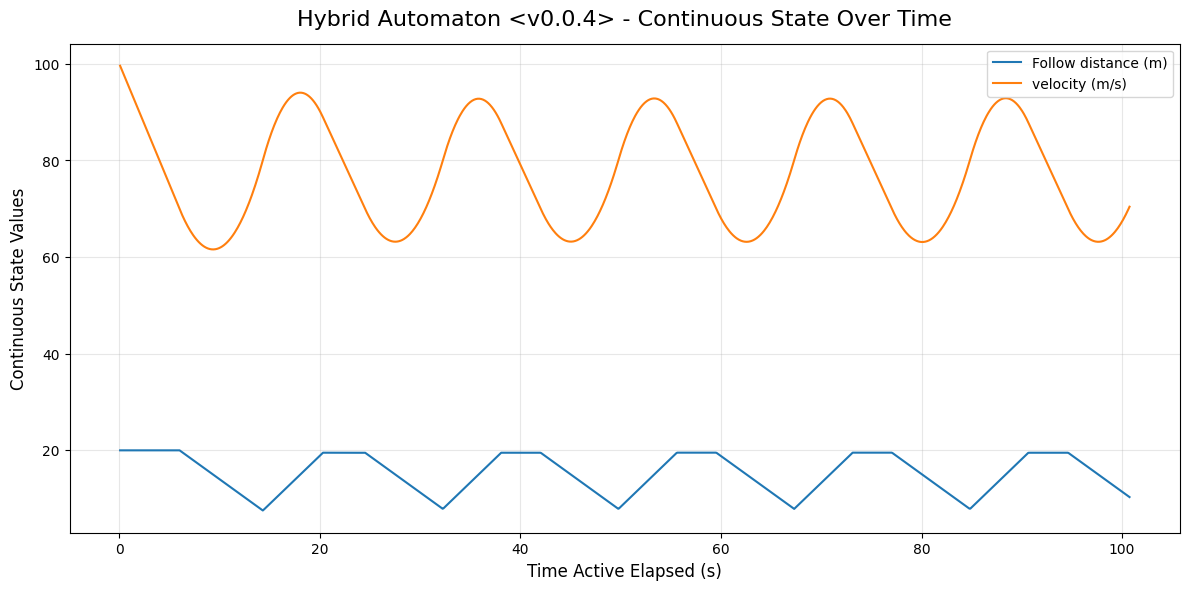

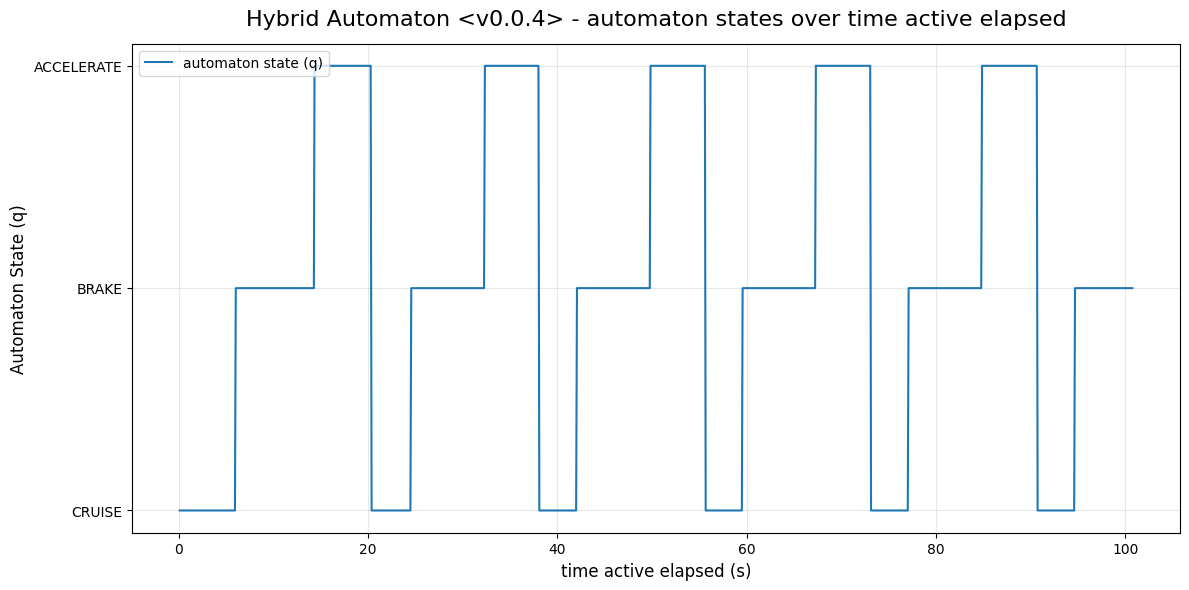

In [6]:
from hybrid_automaton_evaluation.visualization import continuous_states_over_time_fig, automaton_states_over_time, transitions_times_over_time_fig
import matplotlib.pyplot as plt

results = ha_runner.get_results()

fig1 = continuous_states_over_time_fig(results['continuous_states'], ['Follow distance (m)', 'velocity (m/s)']) 
fig2 = automaton_states_over_time(results['automaton_states'])
# fig3 = transitions_times_over_time_fig(results['transition_times'])
plt.show()